<a href="https://colab.research.google.com/github/nagamamo/machine_learning_for_finance/blob/main/6_multi_factor_model_using_ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**6　Understanding Multi-factor Models using Ridge Regression**

In this example, we use ridge regression to extend a single-factor model into a multi-factor model composed of multiple common factors in the market. Here, we compare the differences in results between Lasso regression and ridge regression using the stock price returns of Toyota (7203.JP) and Honda (7267.JP).

**1. Import Libraries**

To begin this implementation, we import six libraries: ***pandas*** and ***numpy*** for statistical analysis and numerical calculations, ***matplotlib*** for graph creation, and ***sklearn*** for Ridge regression analysis.

In [1]:
#[1-1]Import General Libraries
import pandas as pd #Library for Data management 1
import numpy as np #Library for Data management 2
import matplotlib.pyplot as plt #Library for data visualization
import datetime

In [2]:
#[1-2]Import Libraries for Machine Learning
from sklearn.model_selection import train_test_split #Library for splitting data into training data and test data
from sklearn.linear_model import RidgeCV

**2. Data Management**

Next, we import dataset stored in the online storage Git-hub and name it *URL*.
Convert this *URL* to the ***pandas dataframe*** format and name it *data*. Converting a dataset into a ***pandas dataframe*** format is a core requirement for becoming proficient in Python. In this example, the dependent variables are the stock price returns of Toyota (7203.JP) and Honda (7267.JP), the independent variables are the Nikkei 225 index (^NKX), three proxy variables are the small-cap effect (SMB) and the value stock effect (HML), four dummy variables representing the day of the week, and eleven dummy variables representing the month are used as control variables.

In [ ]:
#[2]Retrieving data
url = "https://github.com/nagamamo/data/blob/main/6_multi_factor_ridge_data.csv?raw=true"#Obtaining CSV data from an online strage Git-hub
data = pd.read_csv(url)#Converting acquired dataset (url) into pandas dataframe data (data)
df = data.set_index("Date")#Convert date information to index
df=df.dropna()
df.head()

**3. Data Preprocessing**

In lines 1 and 2 below, we change the variable names of the *pandas dataframe* data imported in the previous cells to easier-to-understand variable names. Next, we will preprocess the data. ***sklearn*** *cannot handle a *pandas dataframe* array data as a dataset. This data array must be converted to *ndarray* array. By adding ".value" to the end of the data variable name, you can convert the *pandas dataframe* to the *ndarray*.

In [4]:
#[3]Data Preprocessing
company_list=['Toyota','Honda','Nikkei','SMB','HML','Mon','Tue','Wed','Thu','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov'] #Redefine variable names
df.columns = company_list
X = df[['Nikkei','SMB','HML','Mon','Tue','Wed','Thu','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']].values #Defining independnet variables and transforming data arrays
Y = df[['Toyota']].values #Defining dependent variables and transforming data arrays
#Y = df[['Honda']].values #Defining dependent variables and transforming data arrays

**4. Estimating Beta: ML (Ridge)**

Next, we use ridge regression to estimate the beta value, the small-cap (large-cap) effect, and the value (growth) effect. Both Lasso regression and ridge regression add a penalty term to the mean squared error (MSE) and multiply by a regularization parameter. In the case of Ridge, this regularization parameter uses a squared term to control the amount of regularization applied. Increasing the value of the regularization parameter increases the penalty, causing the coefficient to approach zero. This significantly reduces (or completely eliminates) the importance of certain features in the model, enabling automatic feature selection. Conversely, decreasing the value of the regularization parameter reduces the impact of the penalty, and more features are retained in the model. However, unlike Lasso, in the case of Ridge, it is not common for the coefficient to be zero.

The regularization parameter plays an important role in controlling the complexity of the model. Larger values ​​of this parameter result in a stronger penalty and a simpler model, but at the same time, there is a risk of oversimplification.

On the other hand, smaller values ​​of regularization parameter result in a more complex model and increase the likelihood of overfitting. Cross-validation is commonly used to find the optimal value, which maximizes model performance and enables reliable predictions.

The source code for estimating this regulation parameter using ***sklearn*** is as follows:

L2 regularization improves model interpretability by penalizing regression coefficients, mitigating the influence of unwanted variables. This reduces data noise and enables more reliable predictions.

Looking at the estimation results, compared to the Lasso regression, **all four weekly and eleven monthly control variables remain, but some coefficient values ​​are smaller, reducing coefficient bias.** This means that a model with less coefficient bias can be used when making future predictions for this stock price.

In [ ]:
#[4]Estimating Beta by ML (Ridge): Toyota and Honda
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=0)#Splitting training data and test data
machine = RidgeCV(cv=20).fit(X, Y.ravel())#Definition of ML estimation method
machine.fit(X_train,Y_train.ravel())#Fitting
Y_train_pred=machine.predict(X_train)#Predictions using training data
Y_test_pred=machine.predict(X_test)#Predictions using test data
print('b =  %.4f'% machine.coef_[0])
print('s =  %.4f'% machine.coef_[1])
print('h =  %.4f'% machine.coef_[2])
print(f"Coef: {machine.coef_}")
print(f"Intercept: {machine.intercept_:}")
print(f"R_squared: {machine.score(X_test, Y_test):.6f}")
print(f"L2 Parameter: {machine.alpha_:}")

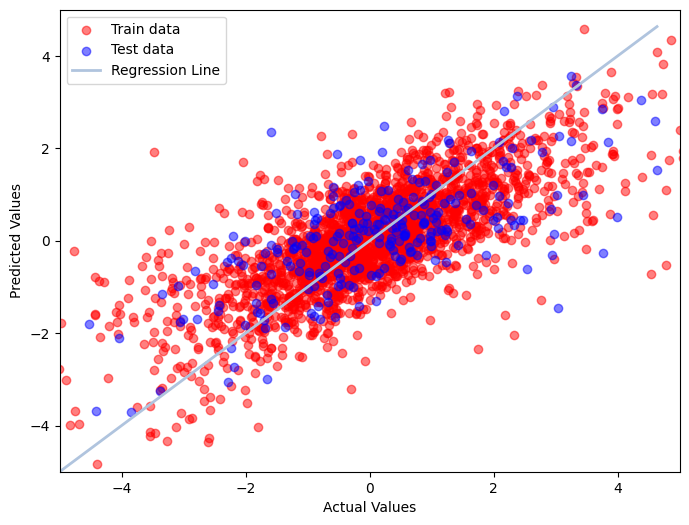

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(Y_train, Y_train_pred, color='red', alpha=0.5, label='Train data')
plt.scatter(Y_test, Y_test_pred, color='blue', alpha=0.5, label='Test data')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='lightsteelblue', linewidth=2, label='Regression Line')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

**5. Visualizing Predicting Data**

In this Lasso estimation, we divide the dataset into multiple training data and test data, and estimate the optimal hyperparameters and beta values by cross-validation. Finally, let's visualize the predictions derived from the training data and the predictions estimated from the test data by ***matplotlib***.

The graph below shows Tesla's stock price return prediction on the horizontal axis and the value obtained by subtracting the actual stock price return from the forecast on the vertical axis. The blue scatters show the training data, and the red scatters show the value calculated using the data.

In general, we would verify by several information criterion to determine the size of this difference, but in this example we  just visualize it.


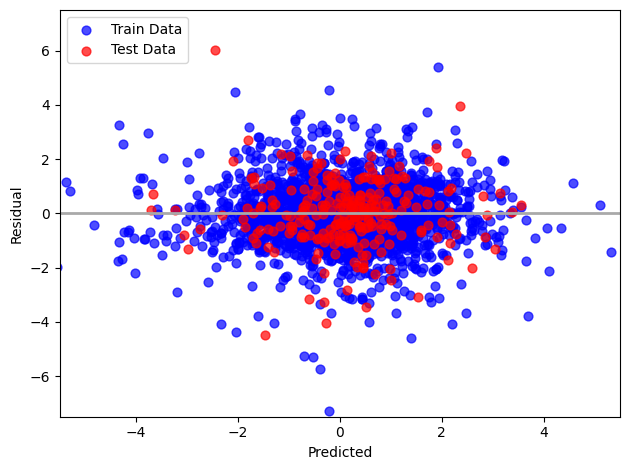

In [8]:
#[7]Visualizing Ridge Regression Results
Y_train_flat = Y_train.ravel()
Y_test_flat = Y_test.ravel()

plt.scatter(Y_train_pred,Y_train_pred-Y_train_flat,c='blue',marker='o',s=40,alpha=0.7,label='Train Data')
plt.scatter(Y_test_pred,Y_test_pred-Y_test_flat,c='red',marker='o',s=40,alpha=0.7,label='Test Data')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.legend(loc='upper left')
plt.hlines(y=0,xmin=-5.5,xmax=5.5,lw=2,color='darkgray')
plt.xlim([-5.5,5.5])
plt.ylim([-7.5,7.5])
plt.tight_layout()
plt.show()